In [2]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [3]:
%run exploratory_analysis.py

No existe ningún dato faltante.

Distribución de clases:
abandono - 1421 - 32.12%
graduado - 2209 - 49.93%
matriculado - 794 - 17.95%

--- INICIO PREPROCESADO FEATURES ---

[Binarias]
 - asistencia_diurna_vespertina → 0=diurna, 1=vespertina
 - becado → 0=no, 1=si
 - desplazado → 0=no, 1=si
 - deudor → 0=no, 1=si
 - genero → 0=hombre, 1=mujer
 - internacional → 0=no, 1=si
 - matricula_al_dia → 0=no, 1=si
 - necesidades_educativas_especiales → 0=no, 1=si

[Ordinales]
 - cualificacion_previa → escala ordinal educativa
 - cualificacion_madre → escala ordinal educativa
 - cualificacion_padre → escala ordinal educativa

[Categóricas → dummies / reducción]
 - estado_civil → one-hot encoding
 - nacionalidad → binaria (portuguesa vs resto)
 - modo_solicitud → agrupación + one-hot
 - curso → agrupación en categorías + one-hot
 - ocupacion_madre/padre → agrupación por sector + one-hot

[Reducción de variables]
 - ratios académicos (presentación y éxito por semestre)
 - eliminación de variables re

## Cargamos el dataset procesado

In [4]:
data = pd.read_csv("rendimiento_estudiantes_procesado.csv", sep=";", encoding="utf-8")
y = data["objetivo"]
data = data.drop(columns="objetivo")

In [5]:
data

,orden_solicitud,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,nota_admision,desplazado,necesidades_educativas_especiales,deudor,matricula_al_dia,genero,becado,edad_al_matricularse,internacional,nota_media_1sem,nota_media_2sem,tasa_desempleo,tasa_inflacion,pib,estado_civil_divorciado/a,estado_civil_separado/a_legalmente,estado_civil_soltero/a,estado_civil_union_de_hecho,estado_civil_viudo/a,modo_solicitud_contingente_especial,modo_solicitud_contingente_general,modo_solicitud_internacional,modo_solicitud_mayor_23,modo_solicitud_titulacion_previa,modo_solicitud_via_legal,carrera_animacion_diseno_multimedia,carrera_comunicacion_marketing,carrera_educacion_basica,carrera_gestion,carrera_salud,carrera_servicio_social,carrera_tecnologia_ingenieria,carrera_turismo,ocupacion_madre_agricultura_pesca,ocupacion_madre_direccion_gestion,ocupacion_madre_fuerzas_armadas,ocupacion_madre_industria_construccion_transporte,ocupacion_madre_no_cualificado,ocupacion_madre_profesional_cualificado,ocupacion_madre_servicios_ventas_cuidados,ocupacion_madre_sin_actividad_o_no_informado,ocupacion_madre_tecnico_intermedio,ocupacion_padre_agricultura_pesca,ocupacion_padre_direccion_gestion,ocupacion_padre_fuerzas_armadas,ocupacion_padre_industria_construccion_transporte,ocupacion_padre_no_cualificado,ocupacion_padre_profesional_cualificado,ocupacion_padre_servicios_ventas_cuidados,ocupacion_padre_sin_actividad_o_no_informado,ocupacion_padre_tecnico_intermedio,ratio_presentacion_1sem,ratio_exito_1sem,ratio_presentacion_2sem,ratio_exito_2sem
0,0.555556,0.0,0.4375,0.284211,1.0,0.296296,0.407407,0.340000,1.0,0.0,0.0,1.0,0.0,0.0,0.056604,0.0,0.000000,0.000000,0.372093,0.488889,0.766182,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.111111,0.0,0.4375,0.684211,1.0,0.518519,0.814815,0.500000,1.0,0.0,0.0,0.0,0.0,0.0,0.037736,0.0,0.741722,0.735897,0.732558,0.111111,0.640687,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.285714,1.000000,0.260870,1.000000
2,0.555556,0.0,0.4375,0.284211,1.0,0.222222,0.222222,0.313684,1.0,0.0,0.0,0.0,0.0,0.0,0.037736,0.0,0.000000,0.000000,0.372093,0.488889,0.766182,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,0.222222,0.0,0.4375,0.284211,1.0,0.259259,0.222222,0.258947,1.0,0.0,0.0,1.0,1.0,0.0,0.056604,0.0,0.711447,0.667692,0.209302,0.000000,0.124174,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.380952,0.750000,0.434783,0.500000
4,0.111111,1.0,0.4375,0.052632,1.0,0.222222,0.259259,0.489474,0.0,0.0,0.0,1.0,1.0,0.0,0.528302,0.0,0.653422,0.700000,0.732558,0.111111,0.640687,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.428571,0.555556,0.260870,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0.666667,0.0,0.4375,0.315789,1.0,0.518519,0.518519,0.286316,0.0,0.0,0.0,1.0,0.0,0.0,0.037736,0.0,0.720530,0.682051,0.918605,0.800000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.714286,0.347826,0.625000
4420,0.222222,0.0,0.4375,0.263158,0.0,0.518519,0.518519,0.252632,1.0,0.0,1.0,0.0,1.0,0.0,0.018868,1.0,0.635762,0.592308,0.406977,0.311111,0.803170,0.0,0.0,1.0

## Vamos a construir un modelo de aprendizaje no supervisado mediante PCA

In [6]:
scaler = StandardScaler(with_std=True, with_mean=True)
data_scaled = scaler.fit_transform(data)

## Ajustamos el modelo PCA

In [7]:
pca = PCA()
pca.fit(data_scaled)
scores = pca.transform(data_scaled)


## Representamos un biplot PCA


c:\Users\migue\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


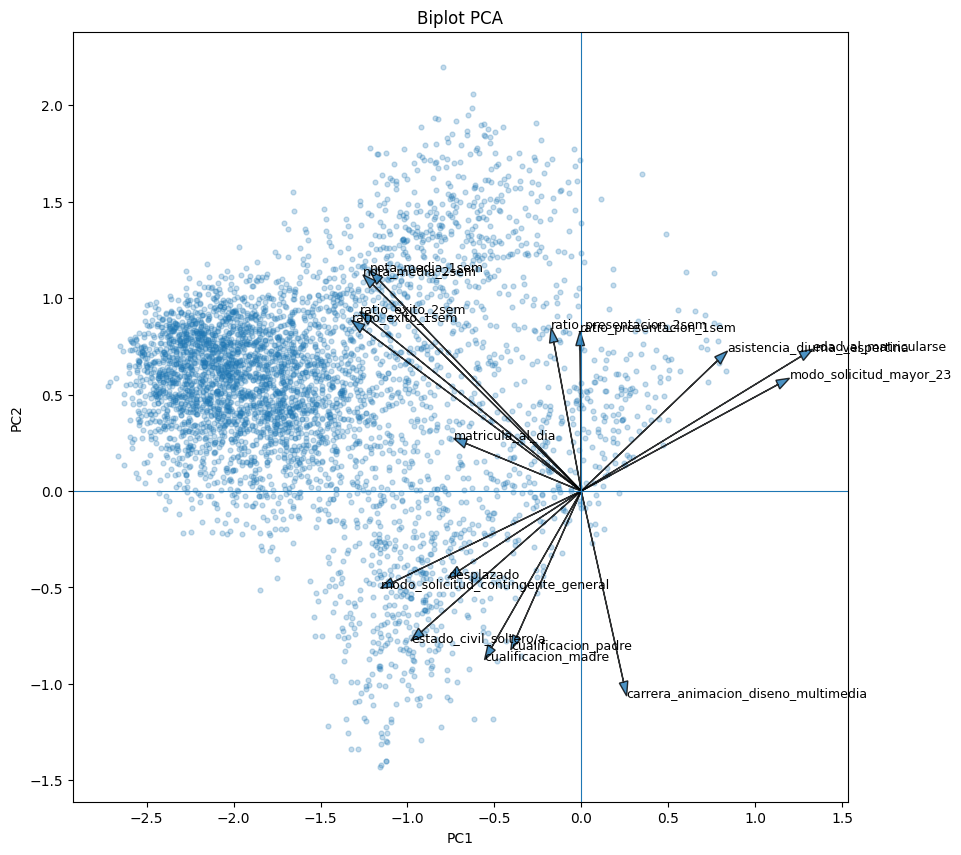

In [8]:
i, j = 0, 1

scores = pca.transform(data)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(scores[:, i], scores[:, j], alpha=0.25, s=12)

# Etiquetas de ejes
ax.set_xlabel(f'PC{i+1}')
ax.set_ylabel(f'PC{j+1}')

scale = 0.7 * np.max(np.abs(scores[:, [i, j]]))

magnitudes = np.sqrt(loadings[:, i]**2 + loadings[:, j]**2)

threshold = np.percentile(magnitudes, 75)   # muestra aprox el 25% más relevante

for k in range(loadings.shape[0]):
    if magnitudes[k] >= threshold:
        x = loadings[k, i] * scale
        y = loadings[k, j] * scale
        
        ax.arrow(
            0, 0, x, y,
            head_width=0.05,
            length_includes_head=True,
            alpha=0.8
        )
        ax.text(
            x, y, data.columns[k],
            fontsize=9
        )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title('Biplot PCA')
plt.show()

In [9]:
explained_ratio = pca.explained_variance_ratio_
cum_explained_ratio = np.cumsum(explained_ratio)

k90 = np.argmax(cum_explained_ratio >= 0.90) + 1
k95 = np.argmax(cum_explained_ratio >= 0.95) + 1

print(f"Número de componentes para llegar al 90% de varianza explicada: {k90}")
print(f"Número de componentes para llegar al 95% de varianza explicada: {k95}")

Número de componentes para llegar al 90% de varianza explicada: 42
Número de componentes para llegar al 95% de varianza explicada: 48


## Vemos cuanta varianza explican los primeros 30 componentes

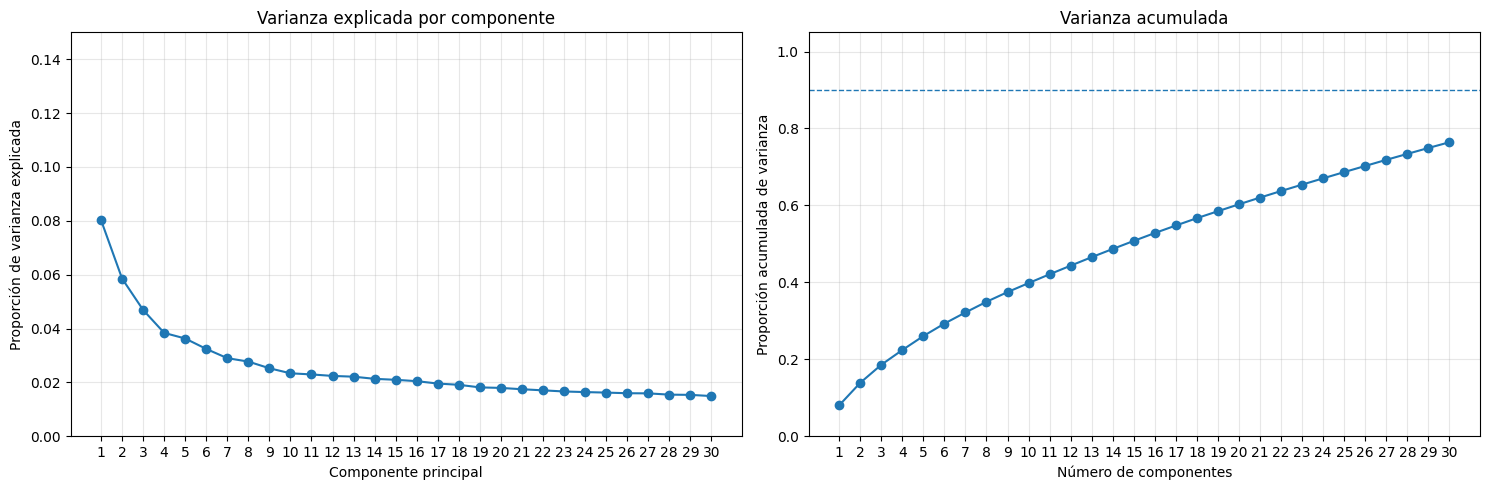

In [10]:
n_show = min(30, len(explained_ratio))
ticks = np.arange(1, n_show + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Varianza explicada por componente
ax = axes[0]
ax.plot(ticks, explained_ratio[:n_show], marker="o")
ax.set_title("Varianza explicada por componente")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de varianza explicada")
ax.set_xticks(ticks)
ax.set_ylim(0, max(0.15, explained_ratio[:n_show].max() * 1.15))
ax.grid(alpha=0.3)

# Varianza acumulada
ax = axes[1]
ax.plot(ticks, cum_explained_ratio[:n_show], marker="o")
ax.axhline(0.90, linestyle="--", linewidth=1)
ax.set_title("Varianza acumulada")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Proporción acumulada de varianza")
ax.set_xticks(ticks)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Visualizamos las dos primeras componentes principales

Text(0, 0.5, 'PC2')

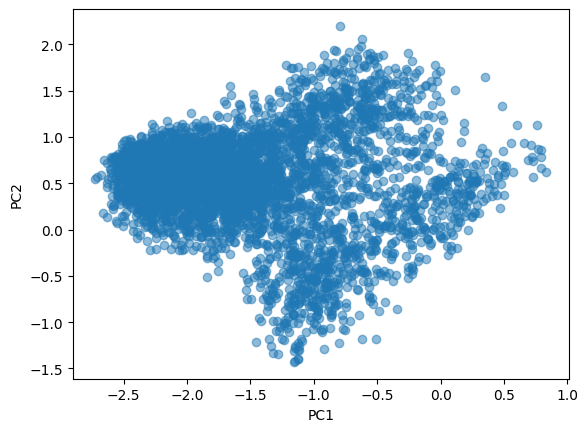

In [11]:
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')

Una vez vista esa estructura, el siguiente paso natural es aplicar clustering para comprobar si existen grupos reales de observaciones con perfiles similares.

## Probamos distintos valores de k para K-Means


In [12]:
k_values = range(2, 9)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(scores)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scores, labels))

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

results_k

,k,inertia,silhouette
0,2,18990.498458,0.114817
1,3,18107.157605,0.057611
2,4,17375.831679,0.058914
3,5,16806.961034,0.062352
4,6,16344.323974,0.061619
5,7,15963.977291,0.066543
6,8,15599.814566,0.069620


## Elegimos el número de clusters mediante el metodo del codo y el de la silueta


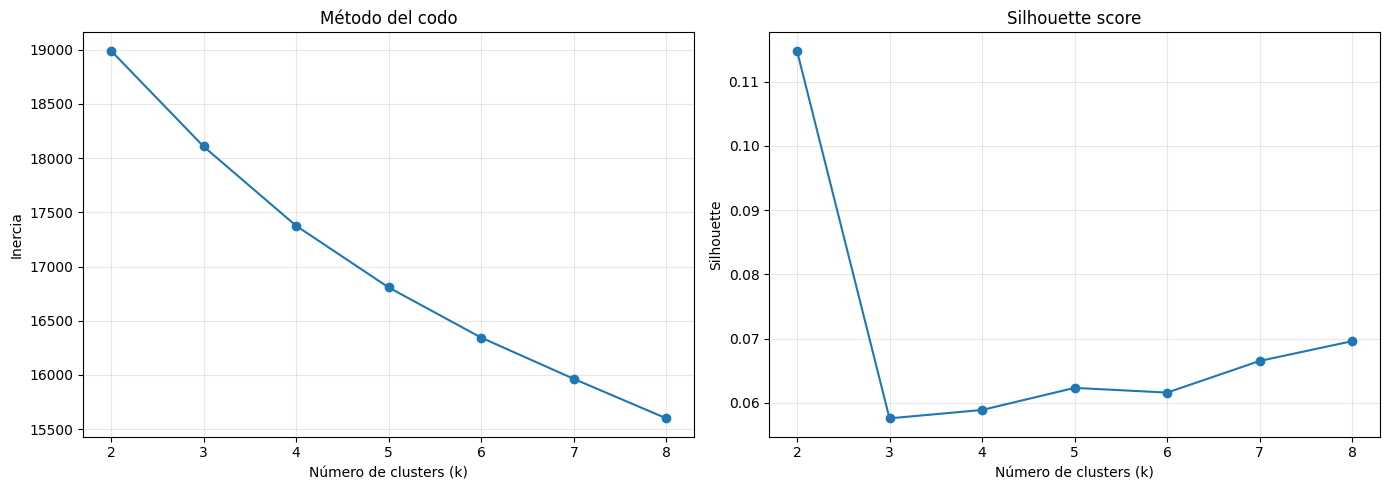

k sugerido por silhouette: 2


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(results_k["k"], results_k["inertia"], marker="o")
ax.set_title("Método del codo")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_xticks(results_k["k"])
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(results_k["k"], results_k["silhouette"], marker="o")
ax.set_title("Silhouette score")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silhouette")
ax.set_xticks(results_k["k"])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = int(results_k.loc[results_k["silhouette"].idxmax(), "k"])
print(f"k sugerido por silhouette: {best_k}")

## Entrenamos el modelo K-Means final


In [14]:
k_final = best_k  # cámbialo si quieres justificar otro valor
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(data_scaled)

df_clusters = data.copy()
df_clusters["cluster"] = cluster_labels

print("Tamaño de cada cluster:")
display(df_clusters["cluster"].value_counts().sort_index())

Tamaño de cada cluster:


cluster
0    1423
1    3001
Name: count, dtype: int64

## Proyectamos los clusters sobre el plano PCA


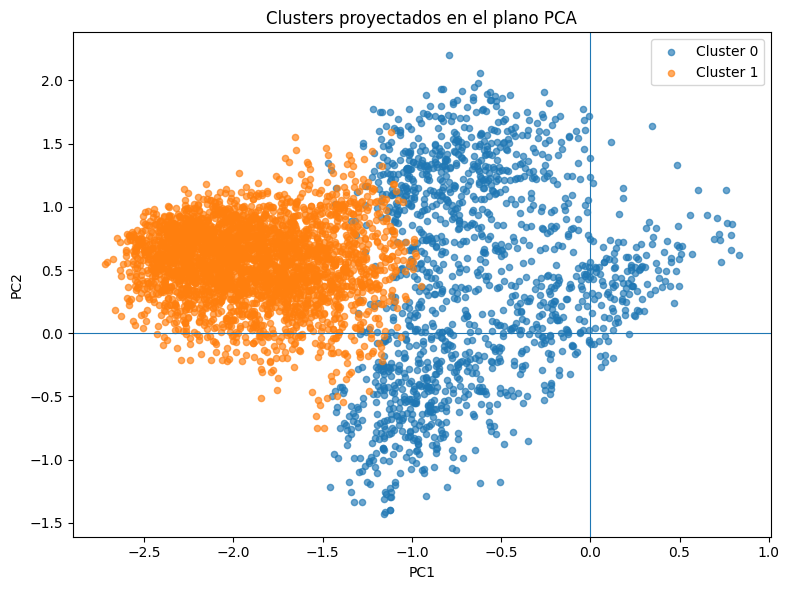

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(np.unique(cluster_labels)):
    mask = cluster_labels == c
    ax.scatter(
        scores[mask, 0],
        scores[mask, 1],
        alpha=0.65,
        s=20,
        label=f"Cluster {c}"
    )

ax.set_title("Clusters proyectados en el plano PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()

## Interpretamos el perfil de los clusters


In [16]:
cluster_profile = df_clusters.groupby("cluster").mean(numeric_only=True)

# Variables más útiles para diferenciar clusters:
between_cluster_std = cluster_profile.std(axis=0).sort_values(ascending=False)
top_profile_vars = between_cluster_std.head(15).index.tolist()

print("Variables con mayor capacidad de diferenciar clusters:")
display(between_cluster_std.head(15))

print("\nPerfil medio por cluster en esas variables:")
display(cluster_profile[top_profile_vars].T)

Variables con mayor capacidad de diferenciar clusters:


modo_solicitud_contingente_general    0.346310
ratio_exito_1sem                      0.317582
modo_solicitud_mayor_23               0.314625
ratio_exito_2sem                      0.308000
nota_media_2sem                       0.276908
nota_media_1sem                       0.249429
desplazado                            0.228796
estado_civil_soltero/a                0.218709
asistencia_diurna_vespertina          0.186534
genero                                0.157133
carrera_salud                         0.146102
becado                                0.144675
matricula_al_dia                      0.143699
edad_al_matricularse                  0.129682
carrera_gestion                       0.114692
dtype: float64


Perfil medio por cluster en esas variables:


cluster,0,1
modo_solicitud_contingente_general,0.278988,0.768744
ratio_exito_1sem,0.250856,0.699985
modo_solicitud_mayor_23,0.479269,0.034322
ratio_exito_2sem,0.235861,0.671438
nota_media_2sem,0.285212,0.676819
nota_media_1sem,0.324469,0.677214
desplazado,0.328883,0.652449
estado_civil_soltero/a,0.676037,0.985338
asistencia_diurna_vespertina,0.288124,0.024325
genero,0.497540,0.719760
